# Augmentation visualization

Loads **one geometry** from `SimVascDataset/` (point cloud + inlet/outlet normals & centers, the same quantities `run_batches` in `main.py` augments) and visualizes what `random_rotation_matrices`, `random_reflection_matrices` and `random_axis_permutation_matrices` (in `modules.py`) actually do to it.

This intentionally **skips** the expensive `phi` (level-set) computation in `load_stl` — augmentation only touches point positions/directions, so we only need `x_dict`, `norm_in`, `norm_out`, `center_in`, `center_out`.

In [ ]:
import os

import numpy as np
import torch
import matplotlib.pyplot as plt

from modules import load_geometry_light, random_rotation_matrices, \
    random_reflection_matrices, random_axis_permutation_matrices, apply_orthogonal_transform

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

In [2]:
# --- validated categorical palette (dataviz skill), fixed order, never cycled ---
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
SURFACE = '#fcfcfb'

# 0=interior, 1=walls, 2=inlet, 3=outlet, 4=outerior (matches Dataset's x_label convention)
LABEL_COLORS = ['#2a78d6', '#008300', '#eda100', '#4a3aa7', '#898781']
LABEL_NAMES = ['interior', 'walls', 'inlet', 'outlet', 'outerior']
NORMAL_COLOR = '#e34948'  # reserved slot for the inlet/outlet normal arrows

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'font.size': 10,
})

## Pick a test geometry

Scans `DATASET_PATH` for the first file matching the same filter `Dataset.__init__` uses in `main.py` (a `*_N.stl` with cached `_interior.pt` / `_outerior.pt`), so this works out of the box against the same dataset layout without hard-coding a case name.

In [3]:
DATASET_PATH = 'SimVascDataset'


def find_first_geometry(dataset_path):
    for case_dir in sorted(os.listdir(dataset_path)):
        case_path = os.path.join(dataset_path, case_dir)
        if not os.path.isdir(case_path):
            continue
        for file in sorted(os.listdir(case_path)):
            if (file.count('_') == 1) and (file.split('_')[-1] != '-1.stl') and ('.stl' in file):
                if file.replace('.stl', '_interior.pt') in os.listdir(case_path):
                    return os.path.join(case_path, file)
    raise FileNotFoundError(f"No cached geometry found under '{dataset_path}/'.")


GEOMETRY_PATH = find_first_geometry(DATASET_PATH)
print(f'Using geometry: {GEOMETRY_PATH}')

Using geometry: SimVascDataset\0018_H_AO_COA\1_1.stl


## Load the geometry

Uses `load_geometry_light` from `modules.py` — mirrors the centering/normalization and boundary-sampling steps of `load_stl`, minus the `phi` fields. Those aren't touched by augmentation, and computing them (`calc_phi` against the full wall mesh) is the expensive part of `load_stl`.

In [ ]:
x_dict, norm_in, norm_out, center_in, center_out = load_geometry_light(GEOMETRY_PATH, device=DEVICE)

x = torch.cat([x_dict['interior'], x_dict['walls'], x_dict['inlet'],
               x_dict['outlet'], x_dict['outerior']], dim=0)
x_label = torch.cat([
    torch.full((len(x_dict['interior']),), 0),
    torch.full((len(x_dict['walls']),), 1),
    torch.full((len(x_dict['inlet']),), 2),
    torch.full((len(x_dict['outlet']),), 3),
    torch.full((len(x_dict['outerior']),), 4),
])

print(f'{len(x)} points loaded, norm_in={norm_in.cpu().numpy()}, norm_out={norm_out.cpu().numpy()}')

## Plot helpers

In [5]:
def set_axes_equal(ax):
    """mplot3d has no built-in equal aspect ratio; without this, rotations look skewed."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    centers = limits.mean(axis=1)
    radius = 0.5 * max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


def plot_geometry(ax, x, x_label, norm_in, norm_out, center_in, center_out, title):
    x_np = x.cpu().numpy()
    label_np = x_label.cpu().numpy()

    for lbl in range(5):
        mask = label_np == lbl
        if mask.any():
            ax.scatter(x_np[mask, 0], x_np[mask, 1], x_np[mask, 2],
                       s=4, color=LABEL_COLORS[lbl], label=LABEL_NAMES[lbl],
                       depthshade=False, linewidths=0)

    for center, norm in [(center_in, norm_in), (center_out, norm_out)]:
        c = center.cpu().numpy()
        n = norm.cpu().numpy()
        ax.quiver(c[0], c[1], c[2], n[0], n[1], n[2],
                  length=0.2, color=NORMAL_COLOR, linewidth=2, normalize=True)

    ax.set_title(title, color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
    ax.xaxis.pane.set_facecolor(SURFACE)
    ax.yaxis.pane.set_facecolor(SURFACE)
    ax.zaxis.pane.set_facecolor(SURFACE)
    set_axes_equal(ax)

## Apply each augmentation

Same composition order as `run_batches` in `main.py`: rotation, then reflection, then permutation. Each panel below isolates one transform (batch size 1, squeezed back to an unbatched point cloud) so you can see what each does independently, plus a combined draw.

In [20]:
torch.manual_seed(13)


def augment_single(x, norm_in, norm_out, center_in, center_out, rotate, reflect, permute, device):
    T = torch.eye(3, device=device, dtype=x.dtype).unsqueeze(0)
    if rotate:
        T = random_rotation_matrices(1, device, x.dtype) @ T
    if reflect:
        T = random_reflection_matrices(1, device, x.dtype) @ T
    if permute:
        T = random_axis_permutation_matrices(1, device, x.dtype) @ T

    x_t, norm_in_t, norm_out_t = apply_orthogonal_transform(T, x.unsqueeze(0), norm_in.unsqueeze(0), norm_out.unsqueeze(0))
    center_in_t, center_out_t = apply_orthogonal_transform(T, center_in.unsqueeze(0), center_out.unsqueeze(0))

    return T[0], x_t[0], norm_in_t[0], norm_out_t[0], center_in_t[0], center_out_t[0]


variants = {
    'original':               dict(rotate=False, reflect=False, permute=False),
    'rotation only':          dict(rotate=True,  reflect=False, permute=False),
    'reflection only':        dict(rotate=False, reflect=True,  permute=False),
    'axis permutation only':  dict(rotate=False, reflect=False, permute=True),
    'combined (all three)':   dict(rotate=True,  reflect=True,  permute=True),
}

results = {}
for name, flags in variants.items():
    results[name] = augment_single(x, norm_in, norm_out, center_in, center_out, device=DEVICE, **flags)

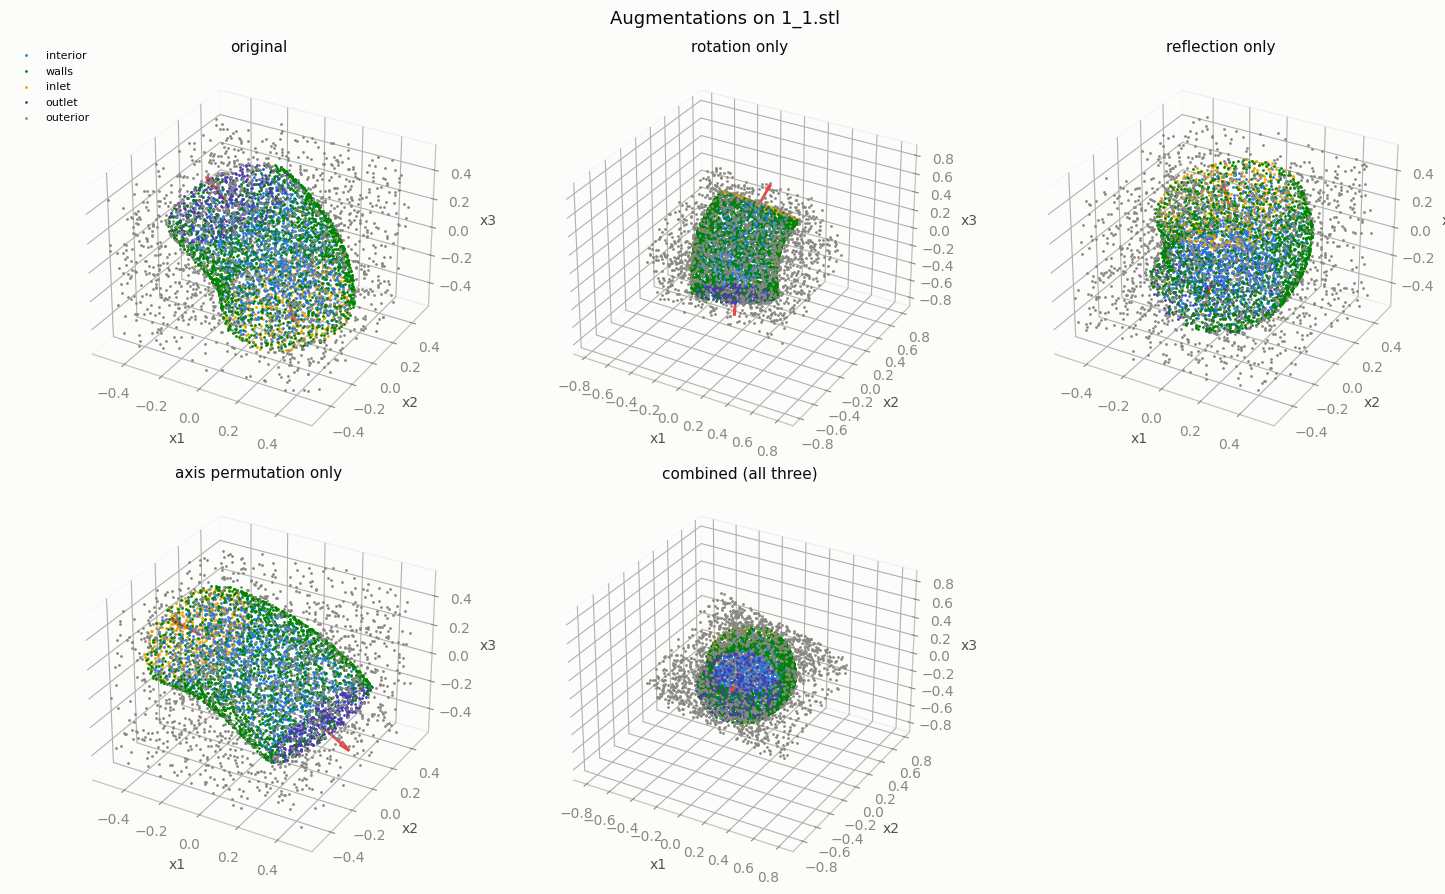

In [21]:
fig = plt.figure(figsize=(15, 9))
for idx, (name, (T, x_t, norm_in_t, norm_out_t, center_in_t, center_out_t)) in enumerate(results.items()):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    plot_geometry(ax, x_t, x_label, norm_in_t, norm_out_t, center_in_t, center_out_t, name)
    if idx == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(-0.15, 1.05), fontsize=8, frameon=False)

fig.suptitle(f'Augmentations on {os.path.basename(GEOMETRY_PATH)}', color=INK_PRIMARY, fontsize=13)
fig.tight_layout()
plt.show()

## Sanity check: the transforms preserve the physics-relevant geometry

`forward()` in `main.py` uses `signed_dist = (x - center_out) \u00b7 norm_out` as a boundary-condition term. Since every augmented tensor gets the **same** per-sample transform `T`, and `T` is orthogonal (`T @ T.T = I`), this dot product must be unchanged by augmentation — verified numerically below for each variant.

In [8]:
orig_signed_dist = ((x - center_out) * norm_out).sum(-1)

for name, (T, x_t, norm_in_t, norm_out_t, center_in_t, center_out_t) in results.items():
    orth_err = (T @ T.T - torch.eye(3, device=DEVICE, dtype=T.dtype)).abs().max().item()
    new_signed_dist = ((x_t - center_out_t) * norm_out_t).sum(-1)
    dist_err = (orig_signed_dist - new_signed_dist).abs().max().item()
    print(f'{name:<24} max |T@T.T - I| = {orth_err:.2e}   max signed-dist mismatch = {dist_err:.2e}   det(T) = {torch.linalg.det(T).item():+.1f}')

original                 max |T@T.T - I| = 0.00e+00   max signed-dist mismatch = 0.00e+00   det(T) = +1.0
rotation only            max |T@T.T - I| = 2.38e-07   max signed-dist mismatch = 2.38e-07   det(T) = +1.0
reflection only          max |T@T.T - I| = 0.00e+00   max signed-dist mismatch = 0.00e+00   det(T) = +1.0
axis permutation only    max |T@T.T - I| = 0.00e+00   max signed-dist mismatch = 1.19e-07   det(T) = -1.0
combined (all three)     max |T@T.T - I| = 1.79e-07   max signed-dist mismatch = 2.38e-07   det(T) = -1.0


In [22]:
from clearml import Task, Dataset


In [25]:
dataset_train = Dataset.get(dataset_name='SimVascDatasetFull', dataset_project='kornaeva-rnf/GA_PINN_3D')

2026-07-17 02:30:02,692 - clearml.storage - ERROR - Could not download s3://api.blackhole2.ai.innopolis.university:443/kornaeva-rnf/kornaeva-rnf/GA_PINN_3D/.datasets/SimVascDatasetFull/SimVascDatasetFull.50d63d9a6c9c4af79286ef422a594f11/artifacts/state/state.json , err: [Errno 28] No space left on device 


ValueError: Could not load Dataset id=50d63d9a6c9c4af79286ef422a594f11 state